In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [12]:
# -------------------- Column Names --------------------
columns = [
    "id",
    "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [13]:
# -------------------- Load Dataset --------------------
data = pd.read_csv("wdbc.data", header=None, names=columns)
data.head()
data.info()
y=data["diagnosis"]
x=data.drop(["diagnosis","id"],axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [14]:
# =======================
# StandardScaler
# =======================


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


KNN accuracy :  0.9649122807017544
KNN confusion matrix :  [[69  2]
 [ 2 41]]
KNN precision :  0.9534883720930233
KNN recall :  0.9534883720930233
KNN f1 score :  0.9534883720930233


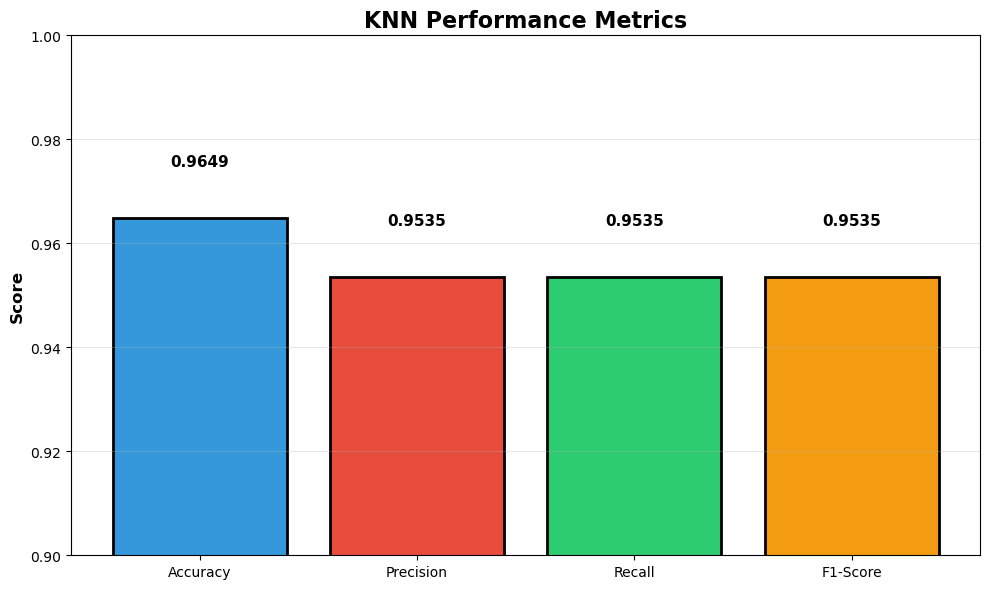

In [15]:
# =======================
# KNN
# =======================

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN accuracy : ", knn_acc)
knn_conft = confusion_matrix(y_test, y_pred_knn)
print("KNN confusion matrix : ", knn_conft)
knn_p = precision_score(y_test, y_pred_knn, pos_label='M')
print("KNN precision : ", knn_p)
knn_r = recall_score(y_test, y_pred_knn, pos_label='M')
print("KNN recall : ", knn_r)
knn_f1 = f1_score(y_test, y_pred_knn, pos_label='M')
print("KNN f1 score : ", knn_f1)

plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [knn_acc, knn_p, knn_r, knn_f1]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
plt.ylim([0.9, 1.0])
plt.title('KNN Performance Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('knn_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Decison tree accuracy :  0.9473684210526315
Decison tree precision :  0.9743589743589743
Decison tree recall:  0.8837209302325582
Decison tree f1 score :  0.926829268292683


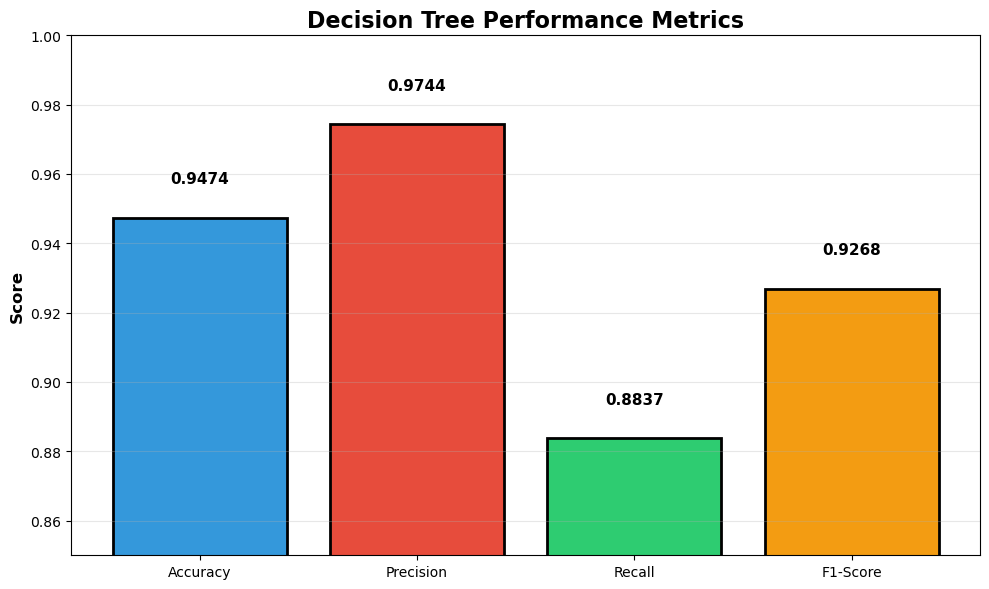

In [16]:
# =======================
# DecisionTree
# =======================

tree_model =  DecisionTreeClassifier (criterion = 'entropy',random_state=42)
tree_model.fit(x_train,y_train)
y_pred_tree = tree_model.predict(x_test)
tree_acc = accuracy_score (y_test,y_pred_tree)
print ("Decison tree accuracy : ",tree_acc)
tree_p = precision_score (y_test,y_pred_tree,pos_label='M')
print ("Decison tree precision : ",tree_p)
tree_r = recall_score (y_test,y_pred_tree,pos_label='M')
print ("Decison tree recall: ",tree_r)
tree_f = f1_score (y_test,y_pred_tree,pos_label='M')
print ("Decison tree f1 score : ",tree_f)

plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [tree_acc, tree_p, tree_r, tree_f]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
plt.ylim([0.85, 1.0])
plt.title('Decision Tree Performance Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('decision_tree_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Logistic accuracy :  0.9736842105263158
Logistic confusion matrix :  [[70  1]
 [ 2 41]]
Logistic precision :  0.9761904761904762
Logistic recall :  0.9534883720930233
Logistic f1 score :  0.9647058823529412


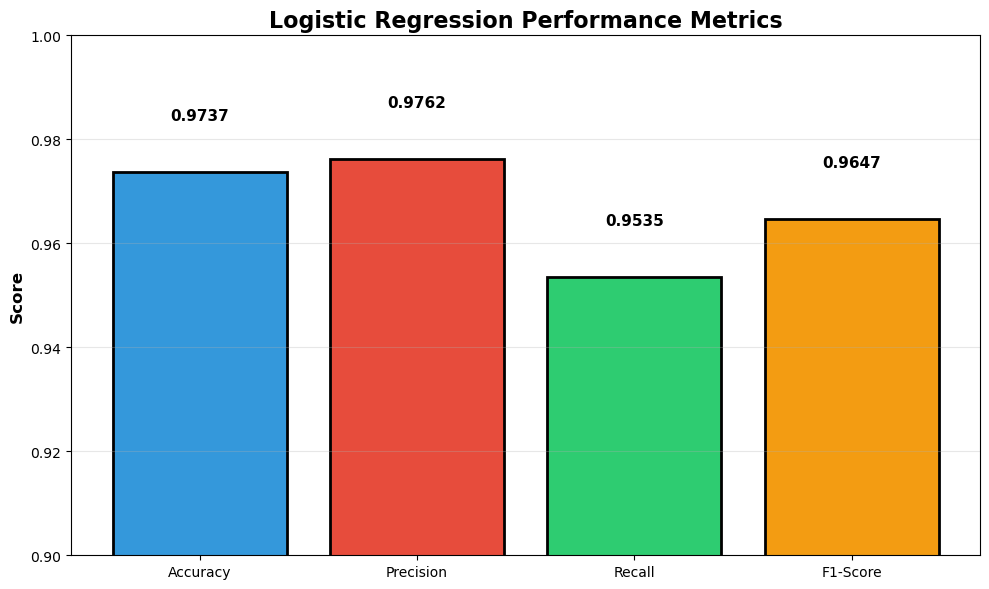

In [17]:
# =======================
# Logistic
# =======================

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(x_test_scaled)
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic accuracy : ", lr_acc)
lr_conft = confusion_matrix(y_test, y_pred_lr)
print("Logistic confusion matrix : ", lr_conft)
lr_p = precision_score(y_test, y_pred_lr, pos_label='M')
print("Logistic precision : ", lr_p)
lr_r = recall_score(y_test, y_pred_lr, pos_label='M')
print("Logistic recall : ", lr_r)
lr_f1 = f1_score(y_test, y_pred_lr, pos_label='M')
print("Logistic f1 score : ", lr_f1)

plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [lr_acc, lr_p, lr_r, lr_f1]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
plt.ylim([0.9, 1.0])
plt.title('Logistic Regression Performance Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('logistic_regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

SVM Accuracy:  0.956140350877193
SVM confusion matrix :  [[68  3]
 [ 2 41]]
SVM precision :  0.9318181818181818
SVM recall :  0.9534883720930233
SVM f1 score :  0.9425287356321839


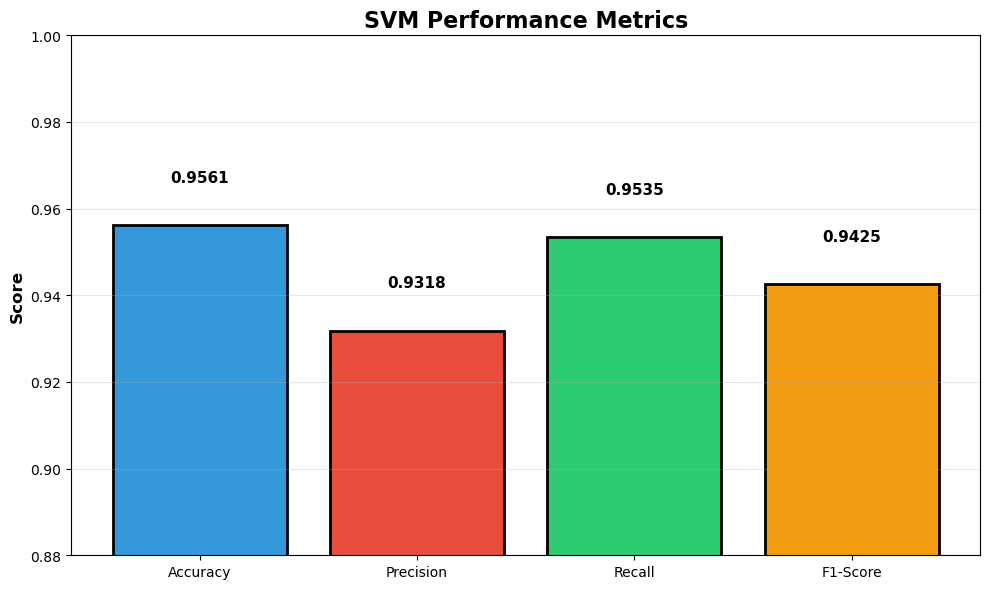

In [18]:
# =======================
# SupportVectorMachine
# =======================


svm_clf = SVC(kernel='linear')
svm_clf.fit(x_train_scaled, y_train)
y_pred_svm = svm_clf.predict(x_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy: ", acc_svm)
svm_conft = confusion_matrix (y_test, y_pred_svm)
print("SVM confusion matrix : ", svm_conft)
svm_p = precision_score (y_test, y_pred_svm,pos_label='M')
print("SVM precision : ", svm_p)
svm_r = recall_score (y_test, y_pred_svm,pos_label='M')
print("SVM recall : ", svm_r)
svm_f1 = f1_score (y_test, y_pred_svm,pos_label='M')
print("SVM f1 score : ", svm_f1)

plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc_svm, svm_p, svm_r, svm_f1]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
plt.ylim([0.88, 1.0])
plt.title('SVM Performance Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('svm_metrics.png', dpi=300, bbox_inches='tight')
plt.show()